In [11]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

%load_ext autoreload
%autoreload 2
%aimport -numpy
%aimport -pandas
%aimport -matplotlib
%aimport -seaborn
%aimport -scipy

print(f"Raiz do projeto: {project_root}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Raiz do projeto: /data_lids/home/gabrielseabra/credit-score-analysis


## 1. Importações e Carregamento de Dados

In [12]:
import matplotlib.pyplot as plt

from src.data.loader import HomeCreditDataLoader
from src.features.build_features import AnomalyHandler, DomainFeatureBuilder
from src.analysis import (
    resumo_estatistico,
    taxa_inadimplencia_por_grupo,
    correlacao_com_target,
    perfil_nulos,
    teste_chi2,
    teste_mann_whitney,
    teste_ks,
    sumarizar_testes,
    plot_distribuicao_target,
    plot_distribuicao_feature,
    plot_correlacao_heatmap,
    plot_taxa_por_categoria,
    plot_ext_sources,
    plot_perfil_nulos,
)

loader = HomeCreditDataLoader(data_dir="../data")
df_raw = loader.load_application_train()
print(f"Dataset: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas")

2026-03-12 18:51:20,635 - HomeCreditDataLoader - INFO - Carregando dados de: application_train.csv...
2026-03-12 18:51:20,766 - HomeCreditDataLoader - INFO - Sucesso! application_train.csv carregado com formato (307511, 122).


Dataset: 307,511 linhas × 122 colunas


## 2. Feature Engineering de Domínio

Antes de analisar, aplicamos os transformadores de `src/features` para:
- Corrigir a anomalia `DAYS_EMPLOYED = 365243` (`AnomalyHandler`)
- Criar as 7 features de negócio derivadas (`DomainFeatureBuilder`)

Isso garante que as análises abaixo usem as mesmas features que entram no modelo.

In [13]:
df = AnomalyHandler().fit_transform(df_raw)
df = DomainFeatureBuilder().fit_transform(df)

# Descrição das features criadas
print(DomainFeatureBuilder.feature_descriptions().to_string(index=False))
print(f"\nShape após feature engineering: {df.shape}")

                 feature                                                                 descricao
     CREDIT_INCOME_RATIO        Crédito total / Renda anual. Razão alta indica superendividamento.
    ANNUITY_INCOME_RATIO            Parcela mensal / Renda anual. Mede o comprometimento de renda.
      CREDIT_TERM_MONTHS                Crédito / Parcela. Prazo implícito do empréstimo em meses.
INCOME_PER_FAMILY_MEMBER        Renda / Membros da família. Proxy de capacidade de pagamento real.
               AGE_YEARS                            Idade do cliente convertida de dias para anos.
          EMPLOYED_YEARS Tempo de emprego convertido de dias para anos (após limpeza de anomalia).
   EMPLOYED_TO_AGE_RATIO                Tempo empregado / Idade. Estabilidade relativa no emprego.

Shape após feature engineering: (307511, 130)


## 3. Variável Alvo (TARGET)

`TARGET = 1` → cliente inadimplente | `TARGET = 0` → cliente adimplente

A taxa base de inadimplência define a **probabilidade a priori** do problema.

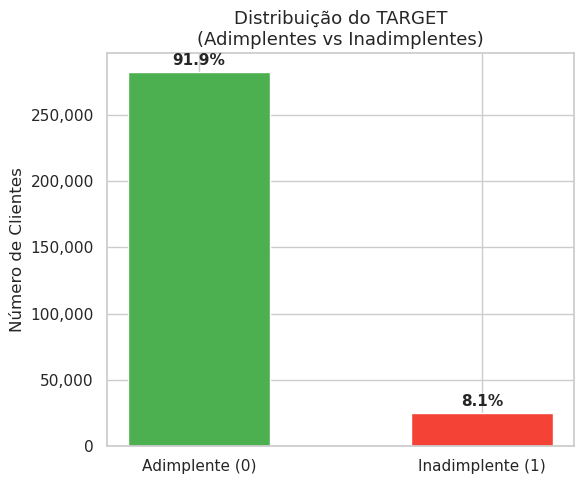

Taxa base de inadimplência: 8.07%
Clientes adimplentes : 282,686
Clientes inadimplentes: 24,825


In [14]:
fig = plot_distribuicao_target(df)
plt.show()

taxa_base = df["TARGET"].mean() * 100
print(f"Taxa base de inadimplência: {taxa_base:.2f}%")
print(f"Clientes adimplentes : {(df['TARGET'] == 0).sum():,}")
print(f"Clientes inadimplentes: {(df['TARGET'] == 1).sum():,}")

## 4. Qualidade dos Dados

### 4.1 Valores Nulos

In [15]:
nulos = perfil_nulos(df)
nulos.head(20)

Colunas com nulos: 73 de 130 (56.2%)
Colunas com >50% nulos: 41


,coluna,n_nulos,pct_nulos,dtype
0,COMMONAREA_AVG,214865,69.87,float64
1,COMMONAREA_MODE,214865,69.87,float64
2,COMMONAREA_MEDI,214865,69.87,float64
3,NONLIVINGAPARTMENTS_MODE,213514,69.43,float64
4,NONLIVINGAPARTMENTS_MEDI,213514,69.43,float64
5,NONLIVINGAPARTMENTS_AVG,213514,69.43,float64
6,FONDKAPREMONT_MODE,210295,68.39,str
7,LIVINGAPARTMENTS_AVG,210199,68.35,float64
8,LIVINGAPARTMENTS_MEDI,210199,68.35,float64
9,LIVINGAPARTMENTS_MODE,210199,68.35,float64


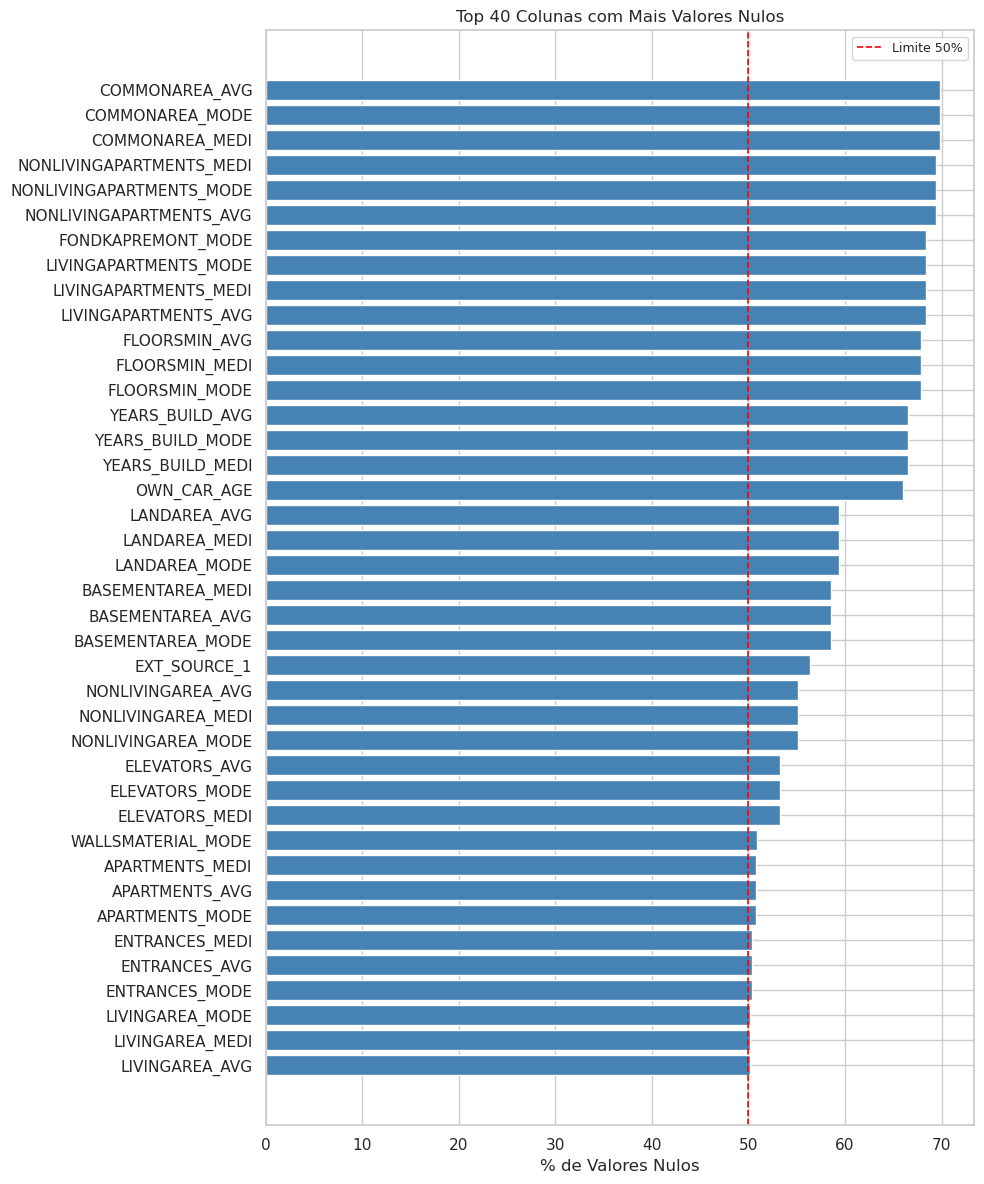

In [16]:
fig = plot_perfil_nulos(df, top_n=40)
plt.show()

### 4.2 Tipos de Dados e Cardinalidade

In [17]:
import pandas as pd

tipos = df.dtypes.value_counts().rename_axis("dtype").reset_index(name="qtd_colunas")
print("Distribuição de tipos:\n", tipos.to_string(index=False))

cols_cat = df.select_dtypes("object").columns
print(f"\nColunas categóricas ({len(cols_cat)}):")
print(df[cols_cat].nunique().sort_values(ascending=False).to_string())

Distribuição de tipos:
   dtype  qtd_colunas
float64           73
  int64           40
    str           16
   int8            1

Colunas categóricas (16):
ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
CODE_GENDER                    3
FLAG_OWN_CAR                   2
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2


/tmp/ipykernel_1130114/1950202282.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat = df.select_dtypes("object").columns


### 4.3 Duplicatas

In [18]:
duplicadas = df.duplicated().sum()
ids_dup = df["SK_ID_CURR"].duplicated().sum()
print(f"Linhas duplicadas    : {duplicadas}")
print(f"SK_ID_CURR duplicados: {ids_dup}")
if duplicadas == 0 and ids_dup == 0:
    print("Sem duplicatas — cada linha é um cliente único.")

Linhas duplicadas    : 0
SK_ID_CURR duplicados: 0
Sem duplicatas — cada linha é um cliente único.


## 5. Estatística Descritiva

In [19]:
resumo = resumo_estatistico(df)

# Features com maior assimetria (skewness) — candidatas a transformação log
print("Top 10 features mais assimétricas:")
print(resumo.sort_values("skewness", ascending=False).head(10)[["media", "mediana", "desvio_padrao", "skewness", "pct_nulos"]])
resumo

Top 10 features mais assimétricas:
                                 media   mediana  desvio_padrao  skewness  \
FLAG_DOCUMENT_12                0.0000       0.0         0.0026  392.1148   
AMT_INCOME_TOTAL           168797.9193  147150.0    237123.1463  391.5597   
FLAG_DOCUMENT_10                0.0000       0.0         0.0048  209.5891   
INCOME_PER_FAMILY_MEMBER    93105.8796   75000.0    101373.3634  187.3673   
FLAG_DOCUMENT_2                 0.0000       0.0         0.0065  153.7918   
AMT_REQ_CREDIT_BUREAU_QRT       0.2655       0.0         0.7941  134.3658   
FLAG_DOCUMENT_4                 0.0001       0.0         0.0090  110.8944   
FLAG_DOCUMENT_7                 0.0002       0.0         0.0139   72.1741   
FLAG_DOCUMENT_17                0.0003       0.0         0.0163   61.2141   
FLAG_DOCUMENT_21                0.0003       0.0         0.0183   54.6129   

                           pct_nulos  
FLAG_DOCUMENT_12                 0.0  
AMT_INCOME_TOTAL                 0.0  


,media,mediana,desvio_padrao,minimo,maximo,skewness,kurtosis,pct_nulos,n_unicos
SK_ID_CURR,278180.5186,278202.0000,102790.1753,100002.0000,4.562550e+05,-0.0012,-1.1990,0.00,307511
CNT_CHILDREN,0.4171,0.0000,0.7221,0.0000,1.900000e+01,1.9746,7.9041,0.00,15
AMT_INCOME_TOTAL,168797.9193,147150.0000,237123.1463,25650.0000,1.170000e+08,391.5597,191786.5544,0.00,2548
AMT_CREDIT,599025.9997,513531.0000,402490.7770,45000.0000,4.050000e+06,1.2348,1.9340,0.00,5603
AMT_ANNUITY,27108.5739,24903.0000,14493.7373,1615.5000,2.580255e+05,1.5798,7.7073,0.00,13672
...,...,...,...,...,...,...,...,...,...
CREDIT_TERM_MONTHS,21.6123,20.0000,7.8238,8.0367,4.530510e+01,0.3047,-0.7826,0.00,39539
AGE_YEARS,43.9069,43.1211,11.9479,20.5038,6.907320e+01,0.1157,-1.0491,0.00,17460
EMPLOYED_YEARS,6.5275,4.5120,6.4021,-0.0000,4.904040e+01,1.9683,4.7527,18.01,12573
EMPLOYED_TO_AGE_RATIO,0.1569,0.1187,0.1335,-0.0000,7.288000e-01,1.3474,1.5926,18.01,250064


## 6. Variáveis Numéricas vs TARGET

### 6.1 Distribuições de Features Financeiras

`plot_distribuicao_feature` separa a distribuição de cada variável entre os dois grupos,
com KDE e boxplot sobrepostos. Medianas divergentes = poder discriminativo.

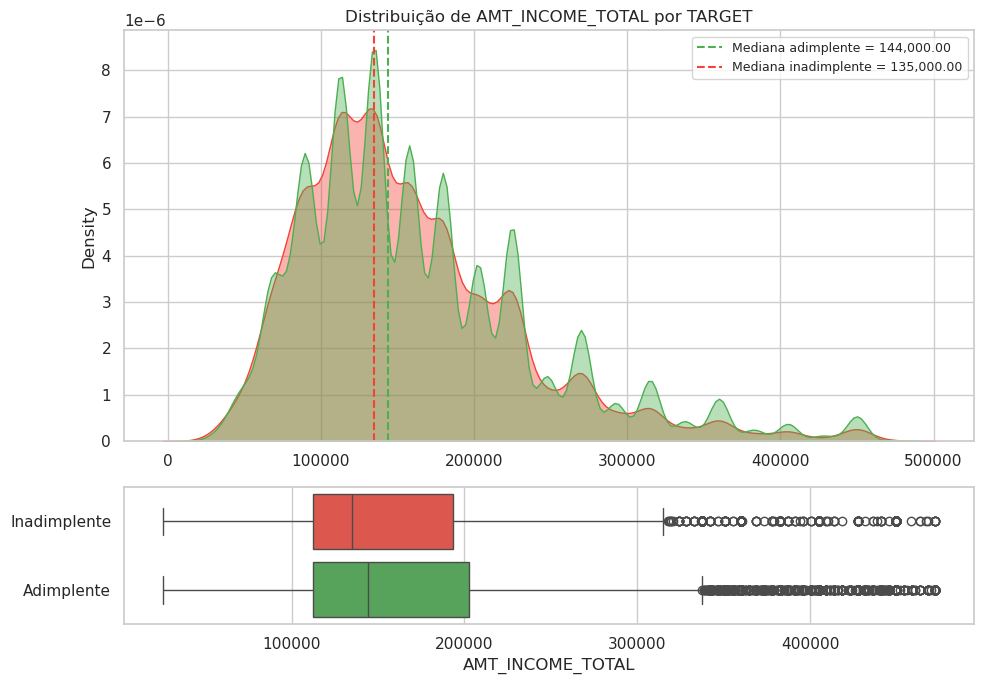

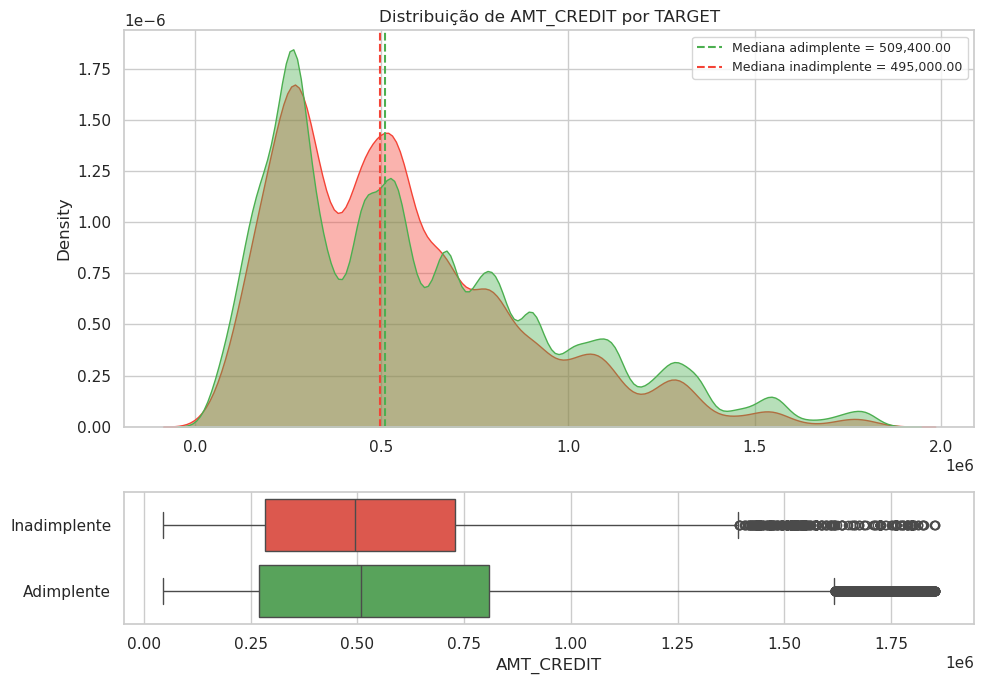

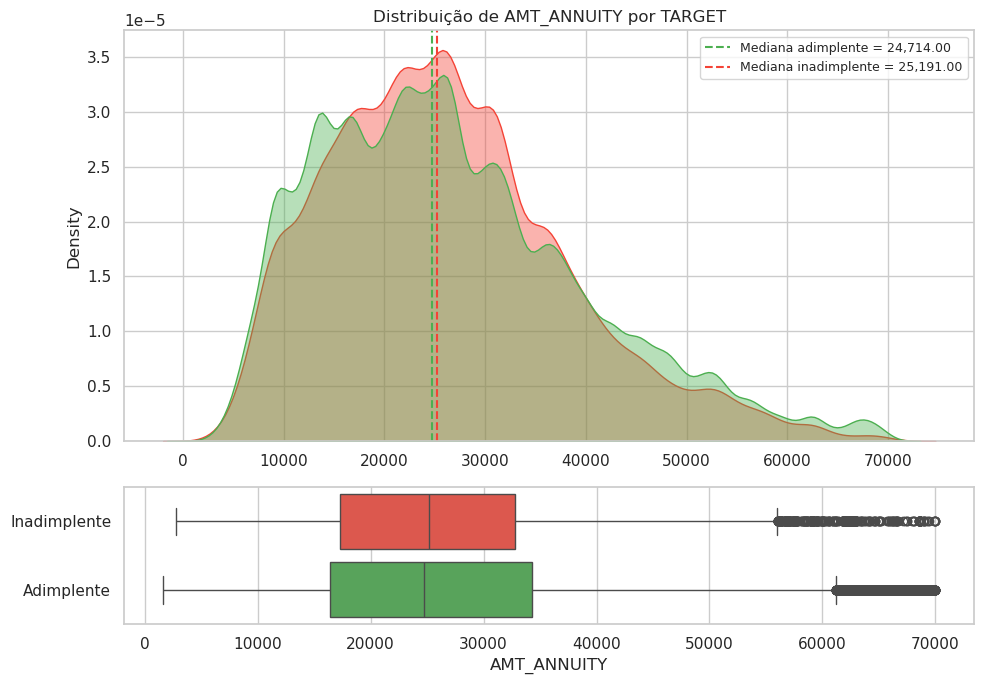

In [20]:
for col in ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]:
    fig = plot_distribuicao_feature(df, col)
    plt.show()

### 6.2 Features de Domínio criadas por `DomainFeatureBuilder`

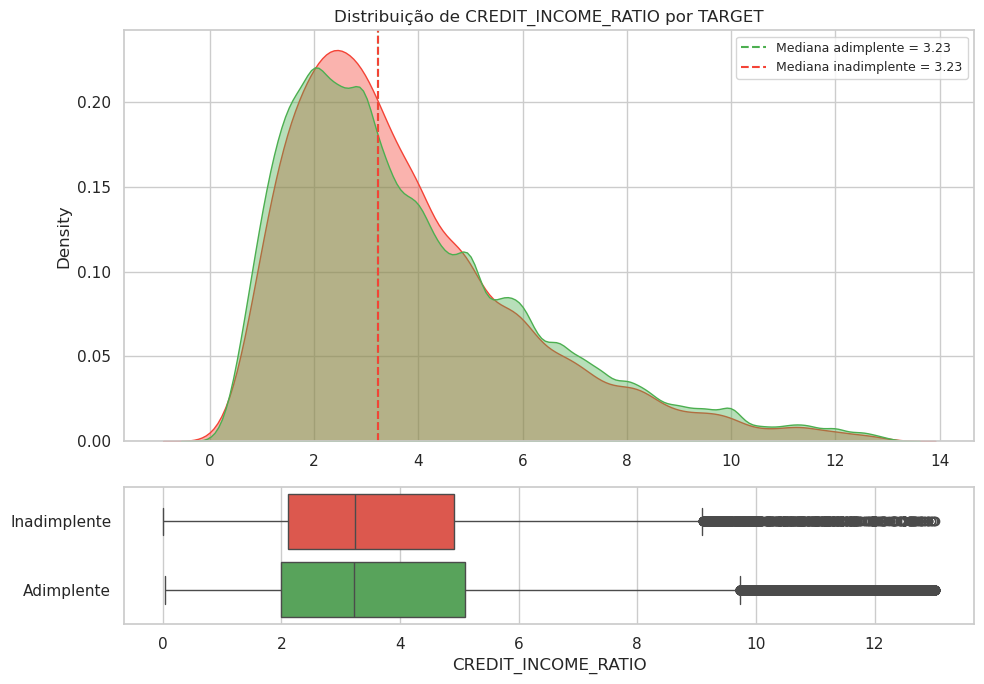

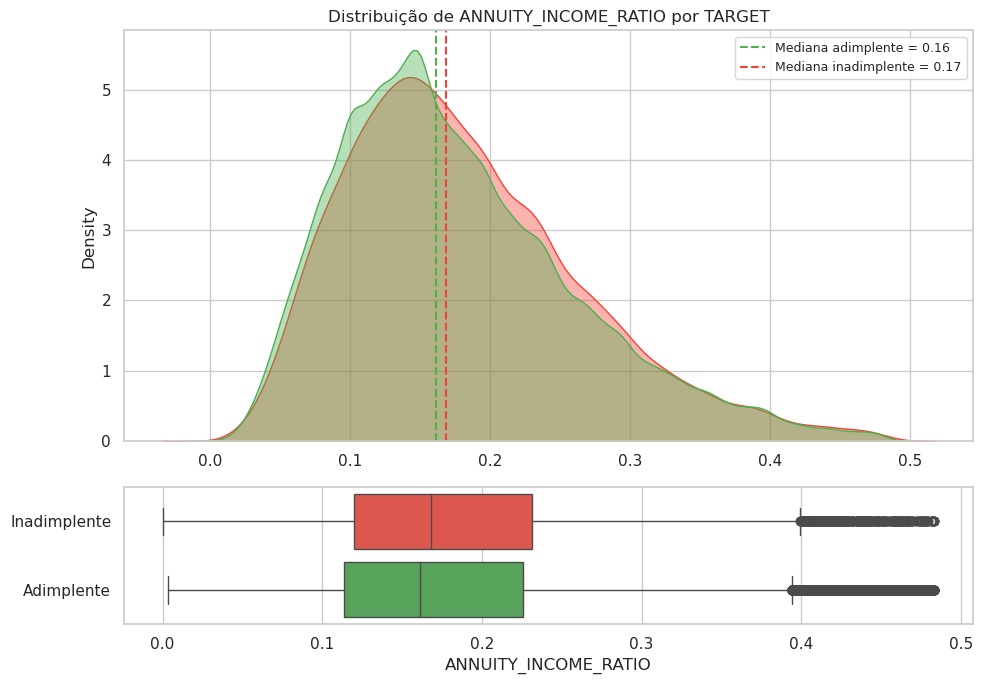

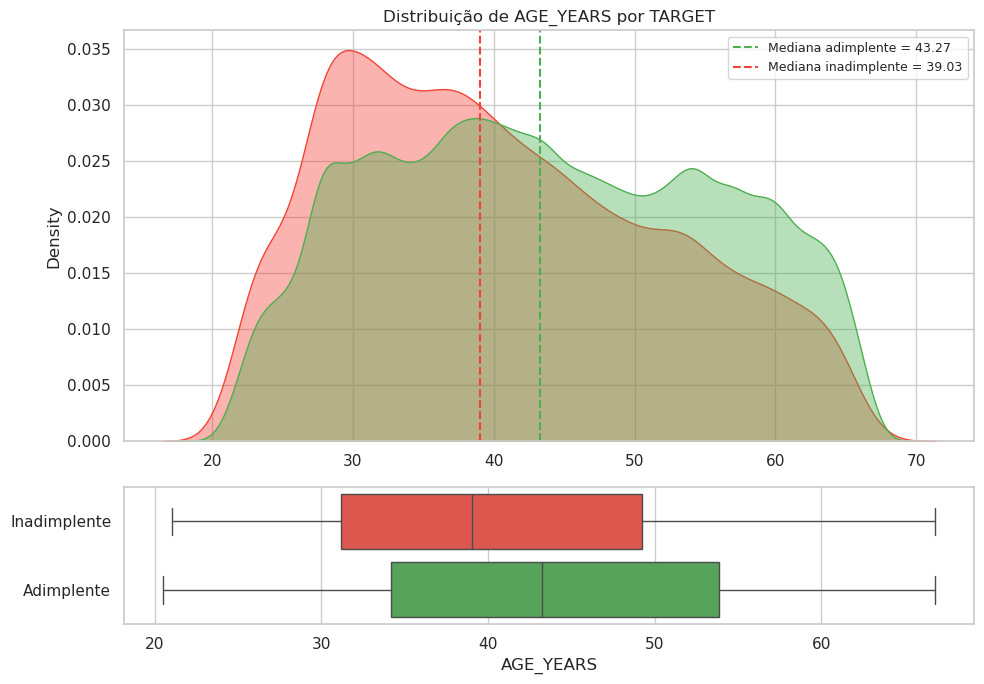

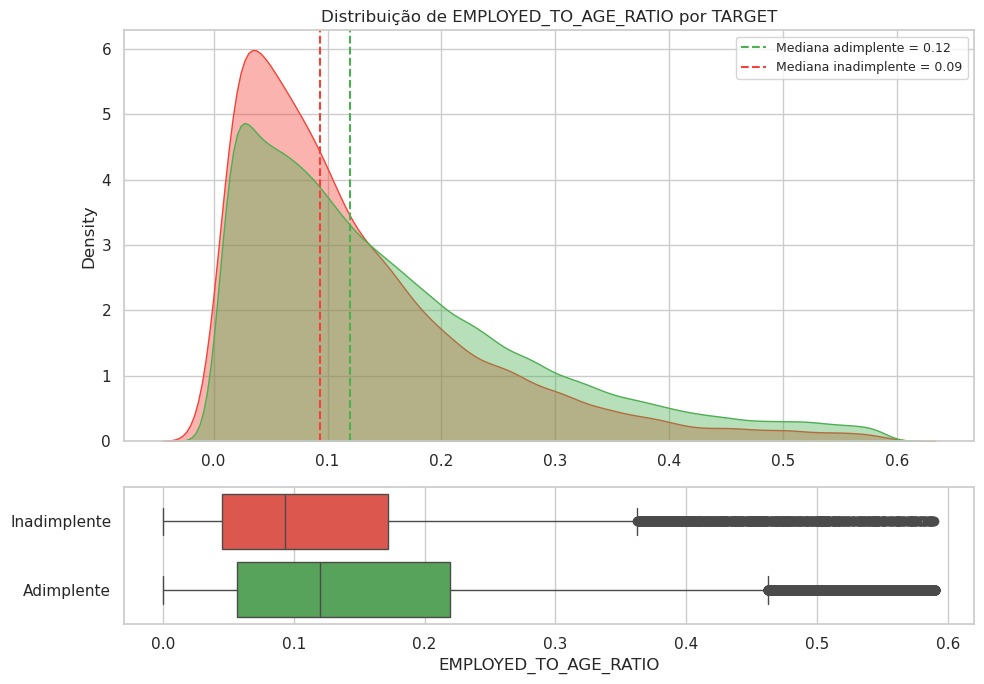

In [21]:
features_dominio = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "AGE_YEARS",
    "EMPLOYED_TO_AGE_RATIO",
]
for col in features_dominio:
    fig = plot_distribuicao_feature(df, col)
    plt.show()

### 6.3 Scores Externos (EXT_SOURCE_1/2/3)

Scores de bureau de crédito externo — costumam ser as features mais preditivas.
Valores mais altos → menor risco percebido pelo bureau.

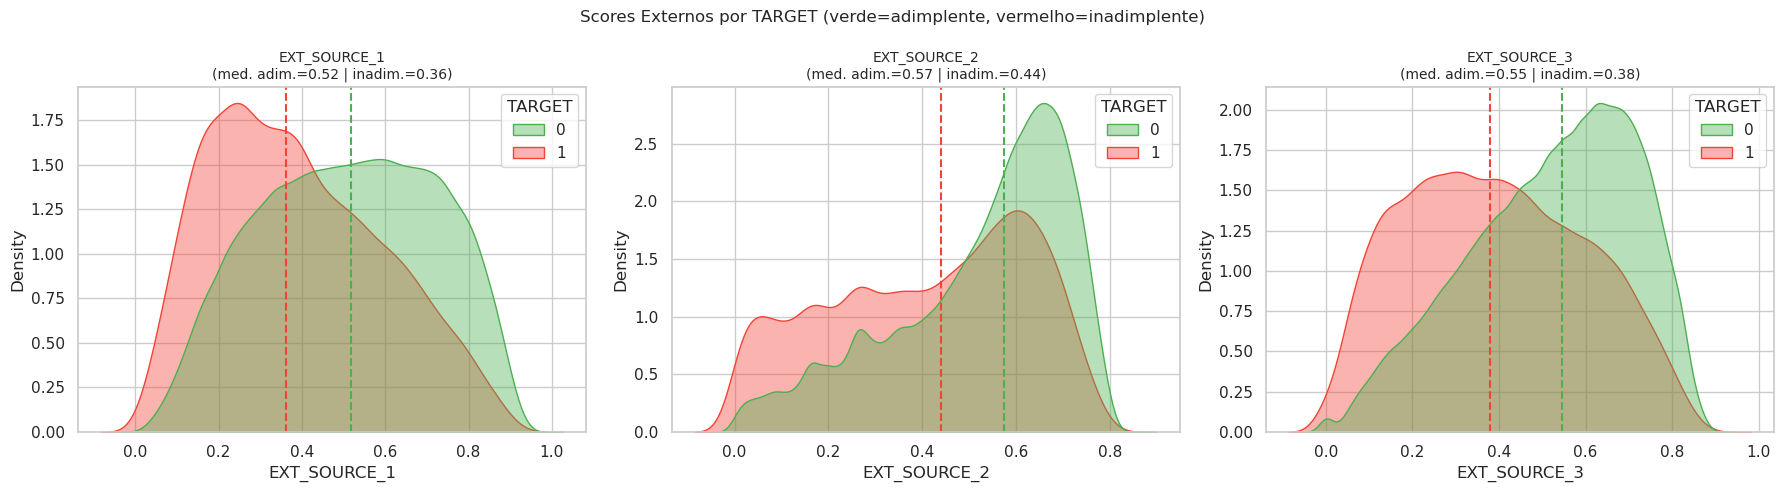

Mediana por TARGET:
TARGET        Adimplente  Inadimplente
EXT_SOURCE_1    0.517452      0.361675
EXT_SOURCE_2    0.573905      0.440381
EXT_SOURCE_3    0.546023      0.379100


In [22]:
fig = plot_ext_sources(df)
plt.show()

print("Mediana por TARGET:")
print(df.groupby("TARGET")[["EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"]]
      .median().T.rename(columns={0:"Adimplente", 1:"Inadimplente"}))

### 6.4 Correlação com TARGET

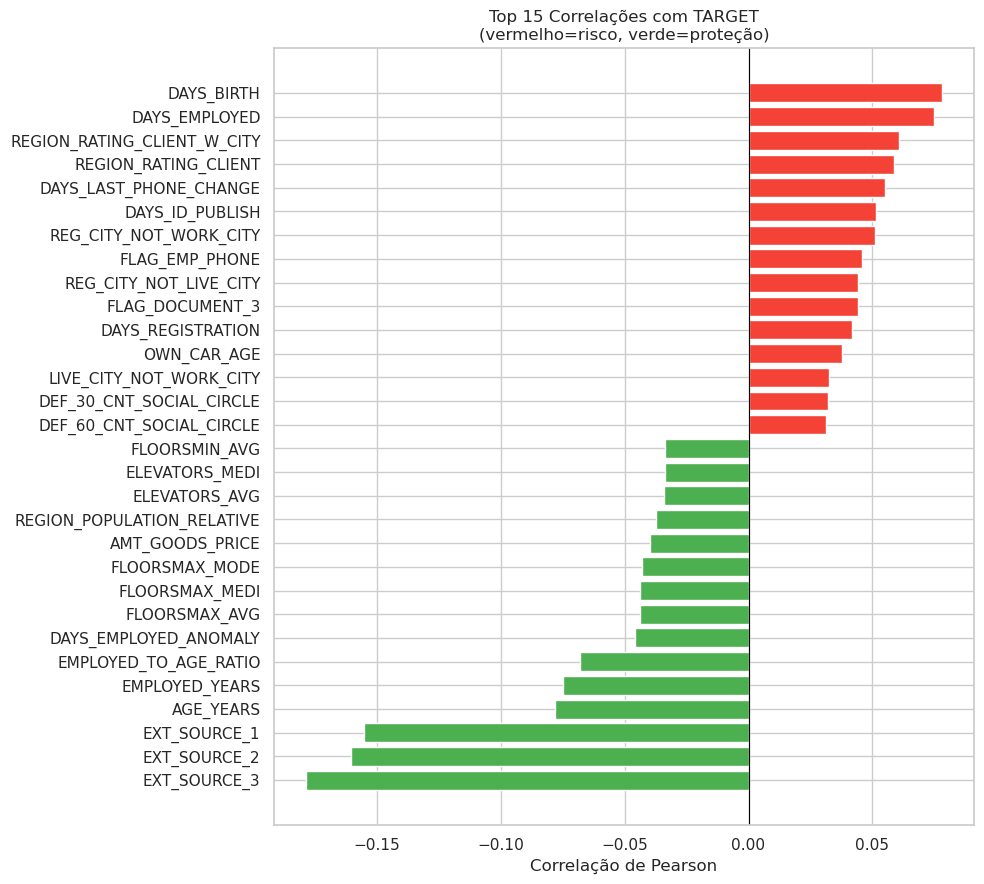


Top 5 proteção (negativas):
EXT_SOURCE_3     -0.178919
EXT_SOURCE_2     -0.160472
EXT_SOURCE_1     -0.155317
AGE_YEARS        -0.078239
EMPLOYED_YEARS   -0.074958
Name: TARGET, dtype: float64

Top 5 risco (positivas):
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_EMPLOYED                  0.074958
DAYS_BIRTH                     0.078239
Name: TARGET, dtype: float64


In [23]:
corr = correlacao_com_target(df, top_n=15)

import matplotlib.pyplot as plt
cores = ["#F44336" if v > 0 else "#4CAF50" for v in corr.values]
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(corr.index, corr.values, color=cores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 15 Correlações com TARGET\n(vermelho=risco, verde=proteção)")
ax.set_xlabel("Correlação de Pearson")
fig.tight_layout()
plt.show()

print("\nTop 5 proteção (negativas):")
print(corr.head(5))
print("\nTop 5 risco (positivas):")
print(corr.tail(5))

## 7. Heatmap de Correlação

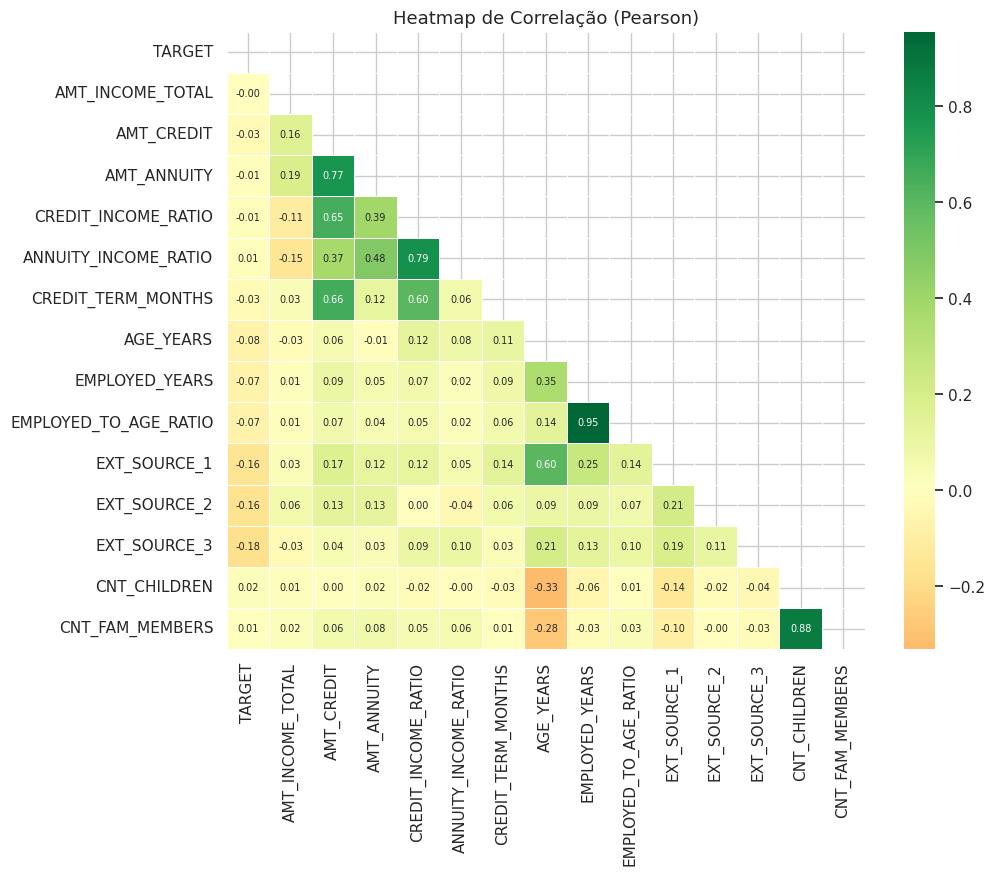

In [24]:
colunas_heatmap = [
    "TARGET",
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
    "CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "CREDIT_TERM_MONTHS",
    "AGE_YEARS", "EMPLOYED_YEARS", "EMPLOYED_TO_AGE_RATIO",
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "CNT_CHILDREN", "CNT_FAM_MEMBERS",
]

fig = plot_correlacao_heatmap(df, colunas_heatmap)
plt.show()

## 8. Variáveis Categóricas vs TARGET

`plot_taxa_por_categoria` calcula e plota a taxa de inadimplência de cada categoria,
com linha de referência na média geral. Categorias acima da linha = maior risco.

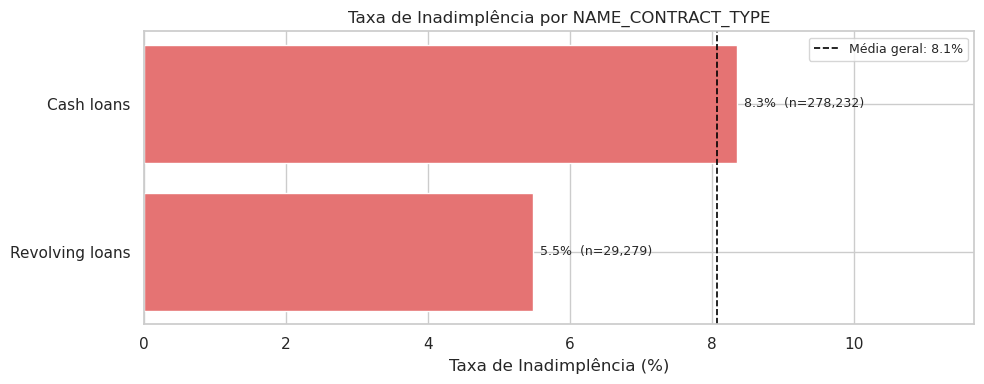

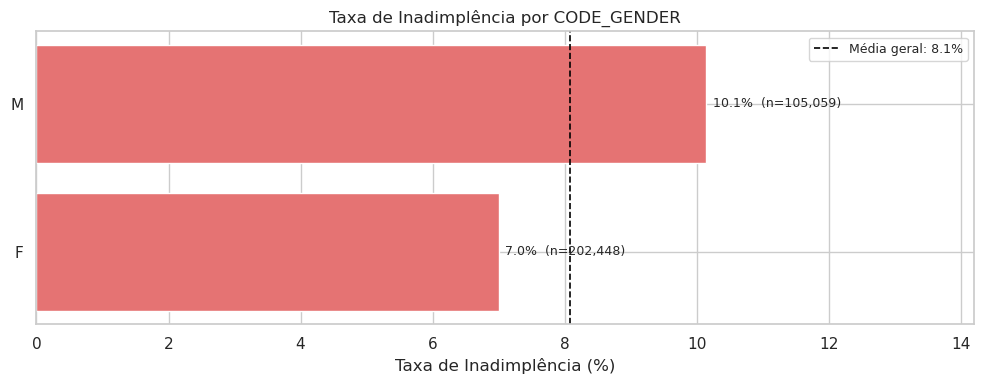

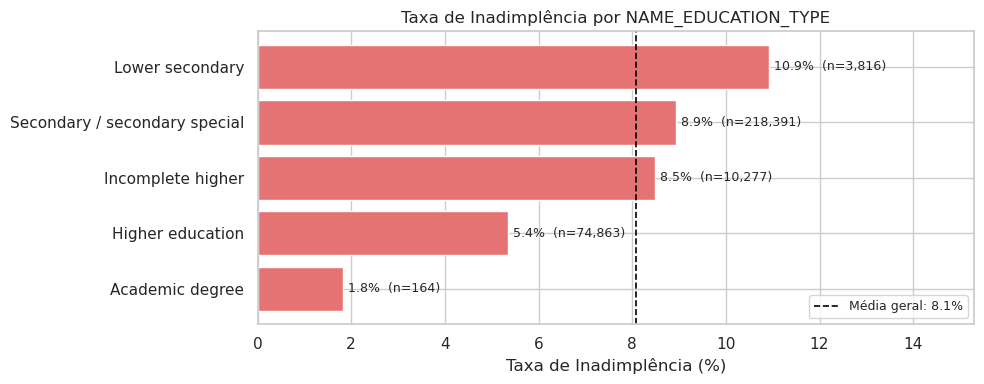

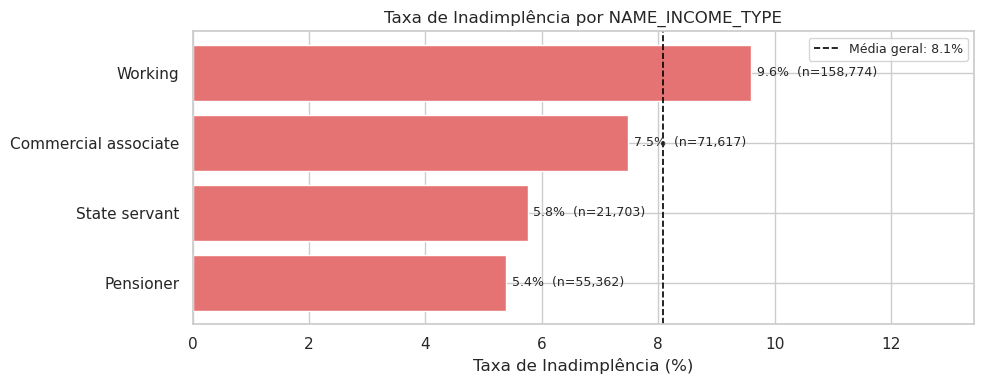

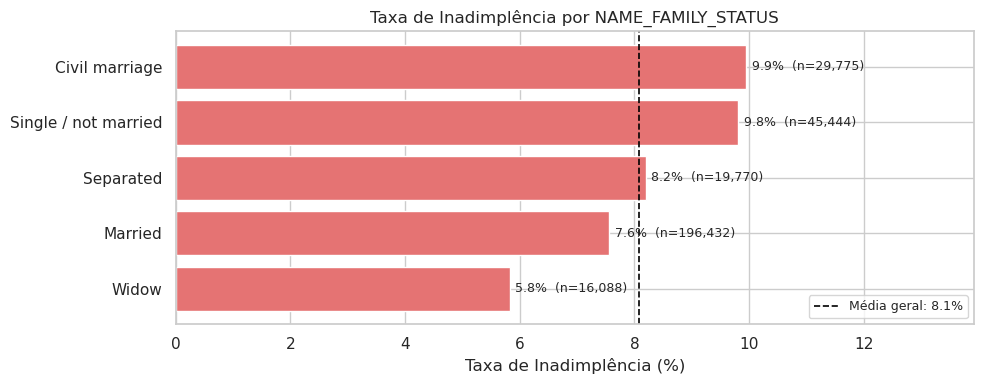

In [25]:
for col in ["NAME_CONTRACT_TYPE", "CODE_GENDER", "NAME_EDUCATION_TYPE",
            "NAME_INCOME_TYPE", "NAME_FAMILY_STATUS"]:
    fig = plot_taxa_por_categoria(df, col)
    plt.show()

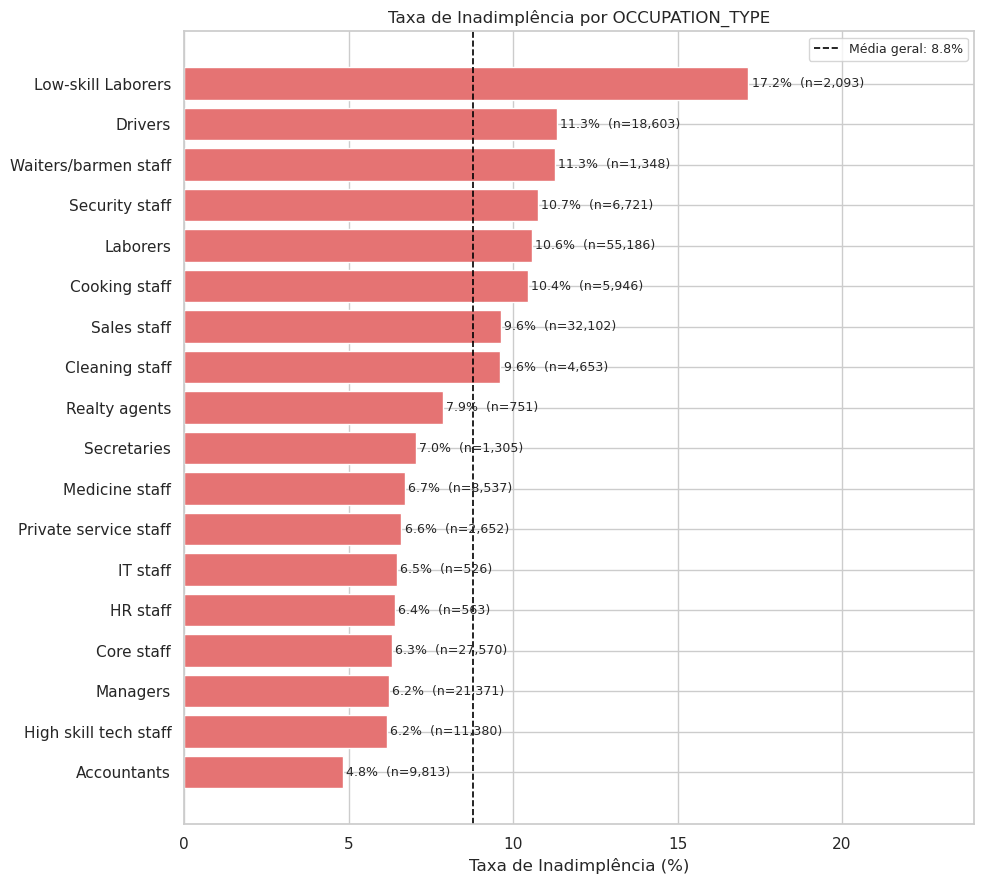

In [26]:
fig = plot_taxa_por_categoria(df.dropna(subset=["OCCUPATION_TYPE"]), "OCCUPATION_TYPE")
plt.show()

### Ranking por `taxa_inadimplencia_por_grupo`

A função retorna uma tabela ordenada — útil para filtrar segmentos de alto risco
sem depender de um gráfico.

In [27]:
for col in ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "OCCUPATION_TYPE"]:
    print(f"\n{'='*60}")
    print(f"  {col}")
    print('='*60)
    print(taxa_inadimplencia_por_grupo(df, col).to_string(index=False))


  NAME_INCOME_TYPE
           categoria  n_clientes  n_inadimplentes  taxa_inadimplencia_pct  diferenca_media_pct
             Working      158774            15224                    9.59                 1.52
Commercial associate       71617             5360                    7.48                -0.59
       State servant       21703             1249                    5.75                -2.32
           Pensioner       55362             2982                    5.39                -2.68

  NAME_EDUCATION_TYPE
                    categoria  n_clientes  n_inadimplentes  taxa_inadimplencia_pct  diferenca_media_pct
              Lower secondary        3816              417                   10.93                 2.86
Secondary / secondary special      218391            19524                    8.94                 0.87
            Incomplete higher       10277              872                    8.48                 0.41
             Higher education       74863             4009        

## 9. Testes de Hipóteses Estatísticos

Testamos formalmente se as diferenças observadas são estatisticamente significativas
ou podem ser explicadas por acaso.

| Variável | Teste | H0 |
|---|---|---|
| Contínua vs TARGET | Mann-Whitney U | Distribuições iguais nos dois grupos |
| Categórica vs TARGET | Qui-Quadrado | Variável independente do TARGET |
| Distribuição completa | Kolmogorov-Smirnov | Distribuições idênticas |

### 9.1 Testes individuais

In [28]:
# Mann-Whitney: renda vs inadimplência
resultado = teste_mann_whitney(df, "AMT_INCOME_TOTAL")
print(resultado)

print()

# KS: EXT_SOURCE_2 (score mais preditivo)
resultado = teste_ks(df, "EXT_SOURCE_2")
print(resultado)

print()

# Chi-quadrado: escolaridade vs inadimplência
resultado = teste_chi2(df, "NAME_EDUCATION_TYPE")
print(resultado)

[Mann-Whitney U] AMT_INCOME_TOTAL
  Estatística = 3643149145.5000 | p-valor = 0.0000e+00
  REJEITA H0 (alpha=0.05) → 'AMT_INCOME_TOTAL' difere significativamente entre grupos (mediana pagador=148500.00, inadimplente=135000.00; p=1.02e-23 < 0.05).

[Kolmogorov-Smirnov] EXT_SOURCE_2
  Estatística = 0.2237 | p-valor = 0.0000e+00
  REJEITA H0 (alpha=0.05) → 'EXT_SOURCE_2' tem distribuições estatisticamente diferentes entre grupos (KS=0.2237; p=0.00e+00 < 0.05). Boa candidata como feature preditiva.

[Qui-Quadrado] NAME_EDUCATION_TYPE
  Estatística = 1019.2132 | p-valor = 0.0000e+00
  REJEITA H0 (alpha=0.05) → 'NAME_EDUCATION_TYPE' tem associação significativa com inadimplência (p=2.45e-219 < 0.05).


### 9.2 Varredura completa de todas as variáveis

In [29]:
sumario = sumarizar_testes(df)

total = len(sumario)
significativas = sumario["rejeita_h0"].sum()
print(f"Variáveis testadas   : {total}")
print(f"Significativas (p<.05): {significativas} ({significativas/total*100:.1f}%)")
print()
print("Top 20 variáveis mais associadas ao TARGET:")
sumario.head(20)

Variáveis testadas   : 96
Significativas (p<.05): 88 (91.7%)

Top 20 variáveis mais associadas ao TARGET:


,variavel,teste,estatistica,p_valor,rejeita_h0
0,CNT_CHILDREN,Mann-Whitney U,3.388674e+09,0.0,True
1,AMT_INCOME_TOTAL,Mann-Whitney U,3.643149e+09,0.0,True
2,AMT_CREDIT,Mann-Whitney U,3.639245e+09,0.0,True
3,AMT_GOODS_PRICE,Mann-Whitney U,3.736227e+09,0.0,True
4,DAYS_BIRTH,Mann-Whitney U,2.926355e+09,0.0,True
5,REGION_POPULATION_RELATIVE,Mann-Whitney U,3.736032e+09,0.0,True
6,DAYS_REGISTRATION,Mann-Whitney U,3.210112e+09,0.0,True
7,DAYS_EMPLOYED,Mann-Whitney U,2.100007e+09,0.0,True
8,REGION_RATING_CLIENT,Mann-Whitney U,3.171548e+09,0.0,True
9,REGION_RATING_CLIENT_W_CITY,Mann-Whitney U,3.163697e+09,0.0,True


In [30]:
nao_significativas = sumario[~sumario["rejeita_h0"]]
if len(nao_significativas) > 0:
    print("Variáveis sem associação significativa com TARGET:")
    print(nao_significativas[["variavel", "teste", "p_valor"]].to_string(index=False))
else:
    print("Todas as variáveis testadas têm associação significativa com TARGET.")

Variáveis sem associação significativa com TARGET:
                  variavel          teste  p_valor
   NONLIVINGAPARTMENTS_AVG Mann-Whitney U 0.053312
  NONLIVINGAPARTMENTS_MEDI Mann-Whitney U 0.121274
                SK_ID_CURR Mann-Whitney U 0.241773
  NONLIVINGAPARTMENTS_MODE Mann-Whitney U 0.261002
       CREDIT_INCOME_RATIO Mann-Whitney U 0.318752
AMT_REQ_CREDIT_BUREAU_HOUR Mann-Whitney U 0.609111
AMT_REQ_CREDIT_BUREAU_WEEK Mann-Whitney U 0.704276
               AMT_ANNUITY Mann-Whitney U 0.967562


## 10. Conclusões da EDA

### Features mais preditivas (baseado nas análises acima)

**Numéricas:**
- `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` — maior separação de distribuição entre grupos
- `CREDIT_INCOME_RATIO`, `ANNUITY_INCOME_RATIO` — ratios financeiros criados em `DomainFeatureBuilder`
- `AGE_YEARS`, `EMPLOYED_TO_AGE_RATIO` — estabilidade e maturidade do cliente

**Categóricas:**
- `NAME_EDUCATION_TYPE` — educação superior tem taxa de inadimplência menor
- `NAME_INCOME_TYPE` — maternity leave e unemployed têm maior risco
- `OCCUPATION_TYPE` — low skill laborers têm maior inadimplência

### Decisões para Modelagem
- **Desbalanceamento**: ~8% de inadimplentes → usar `class_weight='balanced'` ou SMOTE
- **Nulos em EXT_SOURCE_1** (56%): imputar pela mediana via `SimpleImputer`
- **Colunas com >50% nulos**: avaliar remoção (41 colunas)
- **DAYS_EMPLOYED_ANOMALY**: flag binária criada pelo `AnomalyHandler` entra como feature